# Primo circuito: singolo qubit, gate X, misura

Obiettivo: costruire il circuito quantistico più semplice possibile che non sia banale, per prendere confidenza con il flusso di lavoro Qiskit — costruzione circuito, simulazione, lettura dei risultati — prima di affrontare la sfera di Bloch.

**Fisica del circuito.** Partiamo da $|0\rangle$ (stato di default di ogni qubit in Qiskit) e applichiamo il gate $X$, la porta NOT quantistica:
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \qquad X|0\rangle = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix} = \begin{pmatrix}0\\1\end{pmatrix} = |1\rangle$$

Non c'e' sovrapposizione qui: lo stato dopo $X$ è esattamente $|1\rangle$, un autostato della base computazionale. La misura quindi non e' probabilistica in senso non banale — ci aspettiamo il risultato `1` con probabilita' 1 (a meno del rumore statistico di un simulatore ideale, che qui e' zero). Questo e' intenzionale: prima di introdurre la sovrapposizione (H, settimana prossima nel dettaglio) vale la pena verificare che l'intera pipeline — circuito, simulazione, istogramma — funzioni su un caso in cui conosci gia' la risposta.

In [2]:
# --- Imports ---
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

## 1 · Costruzione del circuito

`QuantumCircuit(1, 1)` crea un circuito con 1 qubit quantistico (inizializzato automaticamente a $|0\rangle$) e 1 bit classico (dove verra' scritto il risultato della misura).

Passaggi:
1. `qc.x(0)` — applica il gate $X$ al qubit 0
2. `qc.measure(0, 0)` — misura il qubit 0 nella base computazionale e scrive il risultato nel bit classico 0

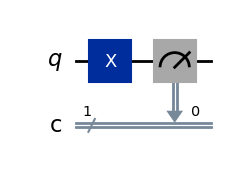

In [3]:
# --- Circuit definition ---

# 1 qubit (starts in |0>) and 1 classical bit to store the measurement outcome
qc = QuantumCircuit(1, 1) 

# Apply the X gate (quantum NOT): |0> -> |1>
qc.x(0)

# Measure the qubit into the classical bit: collapses |1> to the outcome '1'
qc.measure(0, 0)

# Draw the circuit
qc.draw("mpl")

## 2 · Verifica dello stato prima della misura

Prima di simulare con shots, verifichiamo lo stato esatto con `Statevector` — utile per isolare eventuali errori concettuali dal debug del circuito (cosa che farai sistematicamente ogni volta che un circuito non produce l'output atteso). Costruiamo il circuito **senza** la misura per poter leggere il vettore di stato (la misura collasserebbe lo stato e non avrebbe senso chiedere "qual e' il vettore di stato dopo").

In [ ]:
# --- State check (no measurement) ---

qc_check = QuantumCircuit(1)
qc_check.x(0)

sv = Statevector.from_instruction(qc_check)
print("Statevector after X|0>:", sv)

# Expected: [0, 1] i.e. |1> exactly, since X|0> = |1> with no superposition

Statevector after X|0>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


## 3 · Simulazione con shots

**AerSimulator** e' il simulatore locale shot-based. Ogni *shot* e' un'esecuzione indipendente del circuito: lo stato evolve attraverso i gate, poi la misura lo fa collassare a un esito classico campionato dalla distribuzione della regola di Born $p_i = |\langle i|\psi\rangle|^2$. Qui $p_1 = |\langle 1|1\rangle|^2 = 1$ e $p_0 = 0$: ci aspettiamo tutti i 1024 shot su `1`, zero su `0`.

In [5]:
# --- Simulation ---

SHOTS = 1024
backend = AerSimulator()

# transpile() lowers the abstract circuit to the backend's native gate set
compiled = transpile(qc, backend)
job = backend.run(compiled, shots=SHOTS)
counts = job.result().get_counts()

print("Raw counts:", counts)
for bitstring, n in sorted(counts.items()):
    print(f"  |{bitstring}\u27e9  \u2192  {n:4d} shots  ({100*n/SHOTS:.1f}%)")

Raw counts: {'1': 1024}
  |1⟩  →  1024 shots  (100.0%)


## 4 · Istogramma dei risultati

Plot pulito e pronto per una relazione LaTeX: assi etichettati, entrambi gli esiti possibili mostrati esplicitamente (anche `0`, che ha conteggio zero — non va mai omesso un esito solo perche' non si e' verificato, altrimenti il grafico e' fuorviante).

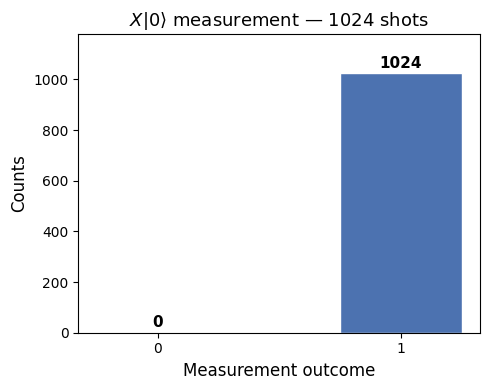

Tutti gli shot danno '1': nessuna sovrapposizione, X|0> = |1> deterministico.


In [6]:
# --- Histogram ---

all_states = ["0", "1"]
values = [counts.get(s, 0) for s in all_states]
colors = ["#4c72b0" if v > 0 else "#d0d0d0" for v in values]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(all_states, values, color=colors, edgecolor="white", width=0.5)

# Annotate each bar with its count
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(val),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_xlabel("Measurement outcome", fontsize=12)
ax.set_ylabel("Counts", fontsize=12)
ax.set_title(f"$X|0\\rangle$ measurement \u2014 {SHOTS} shots", fontsize=13)
ax.set_ylim(0, SHOTS * 1.15)

plt.tight_layout()
plt.show()

print("Tutti gli shot danno '1': nessuna sovrapposizione, X|0> = |1> deterministico.")

## Nota per il prossimo passo

Questo circuito e' deterministico apposta, per isolare la pipeline dal comportamento probabilistico. Nel notebook della Settimana 2 (dopo aver trattato la sfera di Bloch) sostituiremo `qc.x(0)` con `qc.h(0)` e osserveremo la differenza: l'istogramma passera' da un unico picco a ~50/50, ed e' li' che la regola di Born smette di essere banale.